# Squares by flattening every other vertex, then removing it

**N = 5, whose optimum is PROVED: side 2 + 1/2 sqrt(2) = 2.70710678** (`records.py`, from
`data/squaresInSquares.json`). That is the reason to run this size: the answer can be WRONG, not merely
unimpressive. Five unit squares also cannot exceed `phi = 5 / 2.7071^2 = 0.6823`, which is the guard on
whether a result is a packing at all.

**Every polygon is EQUILATERAL at kappa = 4, with its SIZE FREE** -- once the packing has settled.
One family does that: `setConstraints(equilateral = 4.0, edge = False)` pins every edge to
`kappa sqrt(A) / n` computed from the polygon's OWN live area.

The run does NOT start there. The initial placement is wild, and compliance given to a wild
configuration is spent untangling rather than packing -- a free size is worse still, since the cheapest
way to relieve a large overlap is for a polygon to shrink and nothing would object. So sections 1 and
the first half of 2 run RIGID (`area = True, edge = True`, the same shape with the size pinned too),
and the compliance is handed over only once the overlaps are small. `edge = True` cannot express it -- pinning edges to stored numbers fixes
the size too. Measured: a 1.3x rescale about the centroid moves the block residual by 9e-15, so the
constraint sees shape and not size.

    n rows on 2n - 3 shape+size DOF  ->  n - 3 free  =  (n - 4) of shape  +  1 of size

**The sizes are a constrained DEGREE OF FREEDOM, not a schedule.** `area = [1, 2]` holds only the mean
and variance of the areas across the whole packing, so polygons trade size globally while the
distribution is walked to monodisperse. Nothing tells an individual polygon what size to be.

**Compliance is withdrawn by REMOVING VERTICES, and the removal is made exact first.** Blind decimation
does not work: a smooth polygon keeps only 70.7% of its area going 8 -> 4, the area target does not
move, and the constraint projection re-inflates it through a container that is a contact energy and
cannot resist -- measured, that ended at `phi 1.271`, 1.86x the densest packing five squares can have.

So each stage FLATTENS every other vertex before dropping it. `d / (a + b)` is the dimensionless
flatness of a vertex -- 1 exactly when its two neighbours and it are collinear -- and it is scale-free,
which is what lets it work while the sizes are free: an absolute diagonal target would read a polygon
that merely shrank as less flat. Each selected vertex is held against its OWN target
(`flatten = True`), walked from where it started to just short of 1. A collective row was tried and
cannot do it: aimed at exactly flat its gradient vanishes (1 is the bound, so it is a maximum), and
backed off it holds only the mean -- 0.99000 on the nose with the worst vertex at 0.83. Once they are flat, `halveNumEdges` removes them EXACTLY -- it refuses
otherwise, and that refusal is the whole point.

    n_eff    32      16       8       4
    shape    28      12       4       0

Zero at n = 4, where an equilateral quadrilateral with kappa = 4 is a square and nothing else: no
template, no per-object diagonal, no morph, no angle constraint anywhere in the run.

**And it holds EXCESS ENERGY fixed, not density**, re-established after every stage, because removing
vertices moves the jamming density underneath the packing.

In [1]:
import numpy as np
import pyPolygon as pp
from matplotlib import pyplot as plt
import records


## 1. Build equilateral 32-gons at kappa = 4 with a spread of SIZES

`generatePolygons` writes equal edge targets and `P = 4 sqrt(A)`, so the target set is exactly
equilateral at kappa 4. `setLogNormalScale` then spreads the sizes at constant shape -- it rescales each
polygon about its own centroid, so kappa does not move.

Nothing is synced from the geometry: `syncTargetPerimeters` would replace the equal targets with
realized lengths that are equal only to ~1e-07, and `equilateral` needs no stored targets at all.

The build places polygons in a *periodic* box, so some straddle the wall; the spring relax pulls them
in. Run it until `outside()` reaches zero -- the depth tier cannot rescue a polygon whose centroid is
outside, because decompression shrinks each polygon about its own centroid.

n = 17: best known (not proved) is side 4.67553009
densest possible for 17 squares: phi = 0.7777
  as built                 n  32  shapeDOF  28  kappa 4.000000  sizeCV 0.1800  phi 1.03069  side 4.0613  corners     nan
before spring relax: 71 vertices outside the box


FIRE (constrained):  10%| | 417/4000 [01:06<09:32,  6.26it/s, maxF=9


after  spring relax: 88 vertices outside   stop None
  after spring relax       n  32  shapeDOF  28  kappa 4.000000  sizeCV 0.1800  phi 1.03069  side 4.0613  corners     nan


<Axes: >

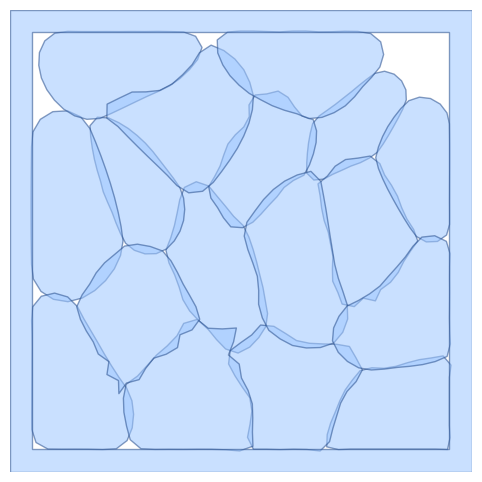

In [2]:
N = 17
n = 32
kappa = 4.0
stages = 3                    # 32 -> 16 -> 8 -> 4, each stage flattens every other vertex then halves
flattenRounds = 8             # steps in the flattening ramp within a stage
# How flat to drive the selected vertices. NOT 1: t = d/(a+b) is at most 1, so 1 is a maximum of t and
# a row aimed exactly there has no gradient left. Stopping just short keeps every row off that
# boundary. The cost is that the removal is not perfectly exact -- measured free-space area loss at
# 32 -> 16 was 2.7e-03 at 0.9999, 2.9e-04 at 0.99999, 6.0e-05 at 0.999999, against the 29% that blind
# decimation cost. halveNumEdges needs t > 0.999952 at that stage, so this clears it with room.
flatGoal = 0.999999
sideLength = np.sqrt(N) * 0.985

print(records.describe(N))
bestKnown = records.bestKnownSide(N)
rigidBaseline = {11: 4.0057}.get(N)
# The densest packing of N unit squares that can exist. Any phi above this once the shapes ARE squares
# is a broken packing, not a better one -- it is the guard that caught the previous protocol.
maxSquarePhi = None if bestKnown is None else N / bestKnown ** 2
print(f"densest possible for {N} squares: phi = {maxSquarePhi:.4f}")

excess = 5e-5                 # how far above jamming to sit, on POLYGON-POLYGON contact alone
sizeSpread = 0.25             # starting CV of the AREA distribution, walked to 0 across the stages
wallStiffness = 100.0         # container stiffness relative to a body contact; 1.0 lets packings leak
coarseness = 1e3
patience = 1000

packing = pp.Model(N = N, n = n, seed = 42)
packing.generateEquilateralPolygons(phi = N / sideLength**2, kappa = kappa)
packing.setLogNormalScale(polydispersity = sizeSpread)

packing.addShape(np.array([[0, 0], [0, 1], [1, 1], [1, 0]]))
packing.pinVertices(np.arange(packing.getNumVertices())[-4:])
packing.setBoundaryConditions("fixed")

def side():
    """Container side if every polygon were rescaled to unit area -- comparable to bestKnown."""
    return float(np.sqrt(N / packing.getPackingFraction()))

def outside():
    r = packing.packing.positions.reshape(-1, 2)[:packing.packing.startIndices[N]]
    return int(((r < 0.0) | (r > 1.0)).any(axis = 1).sum())

def corners():
    """Worst |interior angle - 90| in degrees; NaN until every polygon is a quadrilateral."""
    starts = np.asarray(packing.packing.startIndices, dtype = int)
    stop = int(packing.packing.containerIndex)
    if not np.all(np.diff(starts[:stop + 1]) == 4):
        return float("nan")
    v = packing.packing.positions.reshape(-1, 2)[:starts[stop]].reshape(-1, 4, 2)
    e = np.roll(v, -1, axis = 1) - v
    u = e / np.linalg.norm(e, axis = 2)[:, :, None]
    a = np.degrees(np.arccos(np.clip(np.einsum("pij,pij->pi", -np.roll(u, 1, axis = 1), u), -1., 1.)))
    return float(np.abs(a - 90.0).max())

def count():
    return int(np.diff(packing.packing.startIndices[:2])[0])

def areaMoments(cv):
    """Target [sum A, sum A^2] for the CURRENT mean area at coefficient of variation `cv`.

    Used only in the SIZE SQUEEZE phase, where `area = [1, 2]` is the only moment family live. During
    flattening the areas are held by `area = [1]` alone -- see the cascade cell for why -- which fixes
    the total (so nothing can collapse) while leaving every individual size free to trade.

    Written out rather than going through setTargetPolydispersity, which retargets EVERY active moment
    family at once -- with a flatness family also live that would order the flatness distribution to
    the same CV, which is not what a size sweep means."""
    stop = packing._nonContainer()
    areas = np.asarray(packing.packing.targetArea, dtype = float)[:stop]
    mean = float(areas.mean())
    return np.array([stop * mean, stop * mean ** 2 * (1.0 + cv ** 2)])

def report(label):
    print(f"  {label:24s} n {count():3d}  shapeDOF {count() - 4:3d}  "
          f"kappa {np.nanmean(packing.getShapeIndices()[:N]):.6f}  "
          f"sizeCV {packing.getSizePolydispersity():.4f}  phi {packing.getPackingFraction():.5f}  "
          f"side {side():.4f}  corners {corners():7.3f}")

# RIGID TO START WITH, and deliberately so. The initial placement is wild -- polygons overlapping
# arbitrarily, dozens of vertices outside the box -- and compliance handed to a configuration like that
# is spent on untangling rather than on packing. Worse, a free SIZE lets a polygon shrink its way out
# of an overlap, which is the wrong response entirely: the cheapest way to relieve a huge overlap is to
# stop being big, and nothing here would object.
#
# area = True with equal edge targets is the rigid form of the same shape: equilateral at kappa 4 with
# the size pinned too. The compliant set (equilateral + area = [1], size free) is switched on at the
# end of section 2, once the overlaps are small and the compliance can go into packing instead.
packing.setConstraints(area = True, edge = True)
report("as built")
print(f"before spring relax: {outside()} vertices outside the box")
packing.minimizeFIRE(maxUnbalancedForce = 9e-3, maxSteps = 4000, patience = patience,
                     progressBar = "text")
print(f"after  spring relax: {outside()} vertices outside   stop {packing.getStopReason()}")
report("after spring relax")
packing.draw()

## 2. Settle RIGID, then hand the compliance over

Sections 1 and the first half of this one run with `setConstraints(area = True, edge = True)` -- the
rigid form of the same shape, equilateral at kappa 4 with the size pinned as well. That is deliberate.
The initial placement is wild, and compliance given to a configuration like that is spent untangling
rather than packing; a free size is worse still, because the cheapest way to relieve a large overlap is
for a polygon to shrink, and nothing in the constraint set would object.

Only once the packing has settled and the overlaps are small does the compliant set go on:
`equilateral = 4.0` with `area = [1]`, so the shape is pinned and the size is free to trade. From there
the constraint set does not change again -- what changes is the vertex count, and with it the `n - 4`
shape degrees of freedom.

**The box stays 1 x 1.** `holdExcessEnergy` changes density AFFINELY, resizing the polygons about their
own centroids -- in a fixed box that is exactly affine compression written in the box's frame. Walking
the WALL instead is pathological on the way out: centroids stay at fixed absolute positions, so
decompressing retreats the walls from a cluster that never expands.

**Watch the wall's share of the contact energy.** Body contact and wall penetration are ALTERNATIVES,
not independent terms -- a stressed packing relieves itself through whichever is softer. At
`wallStiffness = 1` the wall wins outright: measured, a state the controller called jammed had 100.00%
of its energy in the wall and a pair overlap of EXACTLY zero.

A caution carried from the previous protocol: at n = 8 the packing sat at `phi 0.926`, and five SQUARES
cannot exceed 0.6823. The density has to come down a long way over the cascade, and the controller has
to follow it. If it does not, the guard in section 4 will say so.

FIRE (constrained):  20%|▏| 1998/10000 [00:59<03:25, 39.00it/s, maxF/home/rdennis/Documents/Code/pyPolygon/model.py:2806: UserWarning: 
*** FIRE stopped at max|F| = 9.27e-06, converging at 0.04 decades per 1000 steps. Reaching the requested 1.0e-07 needs roughly 50,296 more steps, which this run's remaining budget does not cover; raise maxSteps if that is worth it, or relax the tolerance.

  energy, steps, _ = minimize.minimizeFIRE(
FIRE (constrained):  20%|▏| 2000/10000 [00:59<03:56, 33.76it/s, maxF


  FIRE   -> max|F| 9.266e-06   stop slow


L-BFGS (constrained):  20%|▏| 800/4000 [00:30<01:53, 28.20it/s, eval/home/rdennis/Documents/Code/pyPolygon/model.py:3038: UserWarning: 
*** L-BFGS stopped at max|F| = 8.67e-09: 200 steps bought NO reduction at all, and the residual is far above the noise floor (3.0e-12). That is a floor of the ENERGY, not of the minimizer -- a C1 tier has a kink the descent cannot pass, so raise the tolerance or move to a smoother tier rather than spending more steps.

  energy, steps, converged = minimize.minimizeLBFGS(
L-BFGS (constrained):  20%|▏| 800/4000 [00:30<02:02, 26.20it/s, eval

  L-BFGS -> max|F| 8.140e-08   stop flat


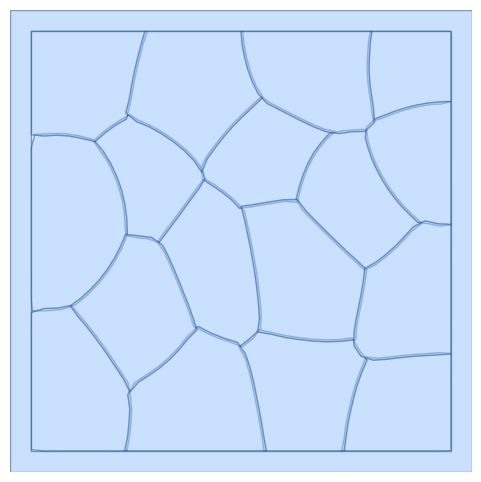

as built: phi 1.03069  side 4.0613  excess 1.455e-02   (asking for 5.0e-05)
  hold     phi 1.030689  excess 1.4557e-02  (target 5.0000e-05)  pairOverlap 2.918e-02
  hold     phi 0.981608  excess 5.3853e-07  (target 5.0000e-05)  pairOverlap 1.018e-04
  hold     phi 1.005849  excess 2.1625e-04  (target 5.0000e-05)  pairOverlap 6.530e-03
  hold     phi 0.993655  excess 3.2104e-07  (target 5.0000e-05)  pairOverlap 8.237e-05
  hold     phi 0.999733  excess 1.5699e-05  (target 5.0000e-05)  pairOverlap 2.207e-03
  hold     phi 1.002787  excess 5.5567e-05  (target 5.0000e-05)  pairOverlap 3.921e-03
  hold     phi 1.002481  excess 4.8167e-05  (target 5.0000e-05)  pairOverlap 3.705e-03

held at excess 4.817e-05:  phi 1.00248  side 4.1180  pairOverlap 3.705e-03
  wall carries 2.90% of the contact energy   120 vertices outside
  at target excess, still rigid n  32  shapeDOF  28  kappa 4.000000  sizeCV 0.1800  phi 1.00248  side 4.1180  corners     nan
  handed over to the compliant set: conditionin

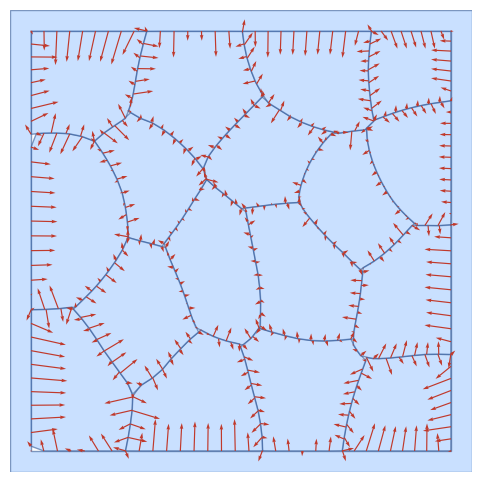

In [3]:
packing.setDepthContact(stiffness = 1.0, wallStiffness = wallStiffness)

# 1e-10, not 1e-12: the force noise floor is 3e-12, so a tighter target is unreachable BY CONSTRUCTION
# and grinds -- below the floor the Wolfe conditions test roundoff and every step burns the full
# 40-bisection cap (measured here: 41.0 evaluations per step against a healthy 1.08). patience stops a
# stalled run and getStopReason() names the wall: 'noise', 'flat', 'slow' or 'search'.
packing.minimizeFIRE(maxUnbalancedForce = 1e-7, maxSteps = 10000, patience = patience,
                     progressBar = "text")
print(f"  FIRE   -> max|F| {packing.getMaxUnbalancedForce():.3e}   stop {packing.getStopReason()}")
packing.minimizeLBFGS(maxUnbalancedForce = 1e-10, maxSteps = 4000, patience = 200,
                      progressBar = "text")
print(f"  L-BFGS -> max|F| {packing.getMaxUnbalancedForce():.3e}   stop {packing.getStopReason()}")
packing.draw()
plt.show()

meanEdge = float(np.mean(packing.getEdgeLengths()[:packing.packing.startIndices[N]]))
print(f"as built: phi {packing.getPackingFraction():.5f}  side {side():.4f}  "
      f"excess {packing.getExcessEnergy():.3e}   (asking for {excess:.1e})")

got, phi = packing.holdExcessEnergy(excess, minimizer = "fireLbfgs", verbose = True)
wallShare = 1.0 - packing.getPairContactEnergy() / packing.getContactEnergy()
print(f"\nheld at excess {got:.3e}:  phi {phi:.5f}  side {side():.4f}  "
      f"pairOverlap {packing.getPairOverlapArea():.3e}")
print(f"  wall carries {100 * wallShare:.2f}% of the contact energy   {outside()} vertices outside")
report("at target excess, still rigid")

# NOW hand the compliance over, with the packing already settled and the overlaps small. equilateral
# holds every edge at kappa sqrt(A)/n from the polygon's OWN live area, so the shape is pinned and the
# size is not; area = [1] fixes only the TOTAL area, which stops the packing collapsing while leaving
# every individual size free to trade. That is the degree of freedom the cascade spends.
packing.setConstraints(equilateral = kappa, edge = False, area = [1])
packing.minimizeFireLBFGS(maxUnbalancedForce = 1e-9, maxSteps = 4000, coarseness = coarseness,
                          patience = patience)
got, phi = packing.holdExcessEnergy(excess, minimizer = "fireLbfgs", maxRounds = 20)
print(f"  handed over to the compliant set: conditioning "
      f"{packing.constraintConditioning():.2e}   {outside()} vertices outside")
report("compliant")
packing.draw(forces = packing.getForces())
plt.show()

## 3. Flatten every other vertex, then remove it -- three times

Each stage does four things:

1. **Select** every other vertex, choosing the phase that is already flattest (`selectFlattening`).
   That is the path of least resistance, and it is the same test `halveNumEdges` uses to decide which
   set to drop, so the two agree on the same vertices by construction rather than by luck.
2. **Constrain their flatness PER VERTEX** -- `flatten = True` over the selected half only, measuring
   `d / (a + b)`, each with its own target that `setFlatTargets` walks. Constraining every vertex
   instead would drive the corners flat too and collapse the polygon.

   A collective row was tried first and cannot do this job. Aimed at exactly `count` it does force
   every term to 1 -- each is at most 1, so the sum reaches count only if all do -- but that is a
   MAXIMUM of the quantity and the row's gradient vanishes there: conditioning 5.97e-01 -> 2.02e-10,
   then LAPACK failed. Backed off to `0.99 count` it is well conditioned but holds only the MEAN, and
   hit 0.99000 exactly while the worst vertex sat at 0.83. In a packing it moved the worst from 0.71 to
   0.80 over eight rounds and was going nowhere. One row per vertex has neither problem.

3. **Ramp** each vertex from where it started to `flatGoal`, just short of flat -- 1 itself is the
   boundary where the gradient dies. The excess is re-established after every step, cheaply, because
   flattening moves the jamming density.

4. **Remove** the flattened vertices with `halveNumEdges`, which is EXACT when they are collinear and
   REFUSES when they are not. The refusal is the safety property: it is what stops the lossy decimation
   that wrecked the previous protocol.

The size distribution is walked toward monodisperse in its OWN phase after each removal, because
moment exponents must match across live families: while the flatness row is up the areas are held by
`area = [1]` alone, which fixes the total so nothing can collapse while leaving every individual size
free to trade. The squeeze then runs with the area family as the only one live, moving its moments
directly. `setTargetPolydispersity` is deliberately not used here -- it retargets every active
moment family at once, and with the diagonal family live that would order the flatness distribution to
the same CV, which is not what a size sweep means.

Watch `worstFlat`: it is the least flat selected vertex, and it has to reach ~1 before `halveNumEdges`
will accept the stage. Two moment rows are COLLECTIVE, so individual vertices can lag the average --
if a stage refuses, that is the diagnosis, and more ramp rounds are the answer.


=== stage 1: n 32 -> 16
  272 vertices selected   worstFlat 0.68299   conditioning 1.00e+00   goal 0.999999
    round  1  worstFlat 0.722618  kappa 4.00000  sizeCV 0.1800  phi 1.00288  side 4.1172  excess 4.86e-05  cond 1.0e+00  [relax 217.7s  hold   3.5s  total    222s]


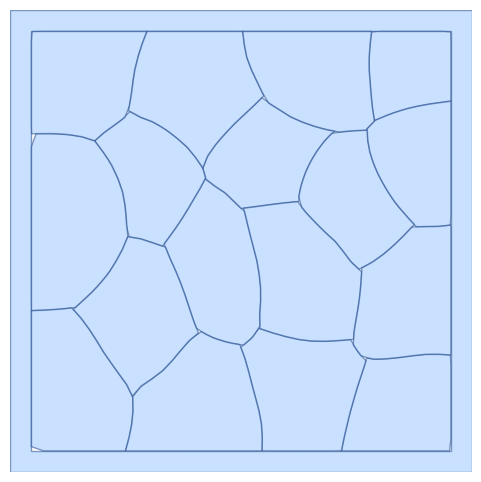

    round  2  worstFlat 0.762244  kappa 4.00000  sizeCV 0.1800  phi 1.00227  side 4.1184  excess 5.07e-05  cond 1.0e+00  [relax 157.7s  hold   6.6s  total    387s]


/home/rdennis/Documents/Code/pyPolygon/model.py:1486: UserWarning: 
*** holdExcessEnergy did not reach 5.000e-05 in 6 rounds ***
    stopped at excess 5.072e-05, phi 1.002265.
    steps within a decade of the target are capped at 1.01x in phi, so a long journey costs rounds -- raise maxRounds, or maxDensityStep to move faster at the price of following the branch less closely.
  return anneal.holdExcessEnergy(


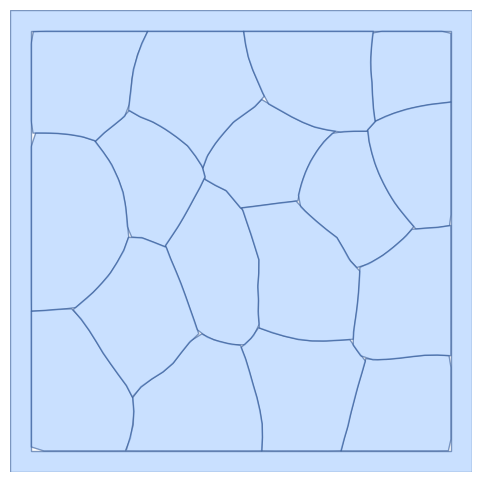

    round  3  worstFlat 0.801870  kappa 4.00000  sizeCV 0.1800  phi 1.00152  side 4.1200  excess 5.19e-05  cond 1.0e+00  [relax 160.3s  hold   4.1s  total    551s]


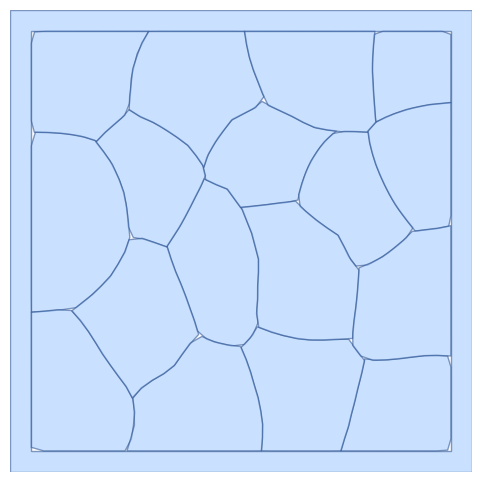

    round  4  worstFlat 0.841496  kappa 4.00000  sizeCV 0.1800  phi 1.00043  side 4.1222  excess 5.16e-05  cond 1.0e+00  [relax 146.7s  hold   6.6s  total    705s]


/home/rdennis/Documents/Code/pyPolygon/model.py:1486: UserWarning: 
*** holdExcessEnergy did not reach 5.000e-05 in 6 rounds ***
    stopped at excess 5.159e-05, phi 1.000428.
    steps within a decade of the target are capped at 1.01x in phi, so a long journey costs rounds -- raise maxRounds, or maxDensityStep to move faster at the price of following the branch less closely.
  return anneal.holdExcessEnergy(


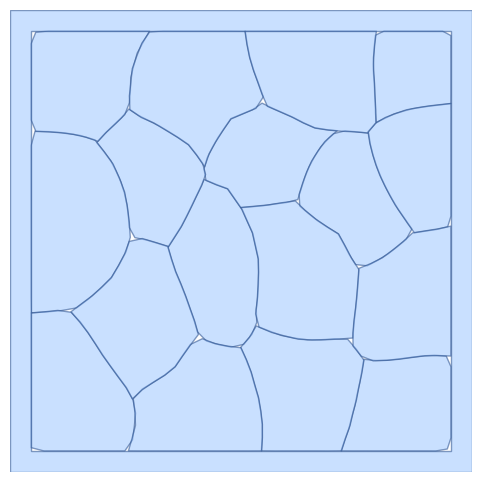

    round  5  worstFlat 0.881121  kappa 4.00000  sizeCV 0.1800  phi 0.99975  side 4.1236  excess 5.07e-05  cond 1.0e+00  [relax 184.0s  hold   6.6s  total    896s]


/home/rdennis/Documents/Code/pyPolygon/model.py:1486: UserWarning: 
*** holdExcessEnergy did not reach 5.000e-05 in 6 rounds ***
    stopped at excess 5.069e-05, phi 0.999754.
    steps within a decade of the target are capped at 1.01x in phi, so a long journey costs rounds -- raise maxRounds, or maxDensityStep to move faster at the price of following the branch less closely.
  return anneal.holdExcessEnergy(


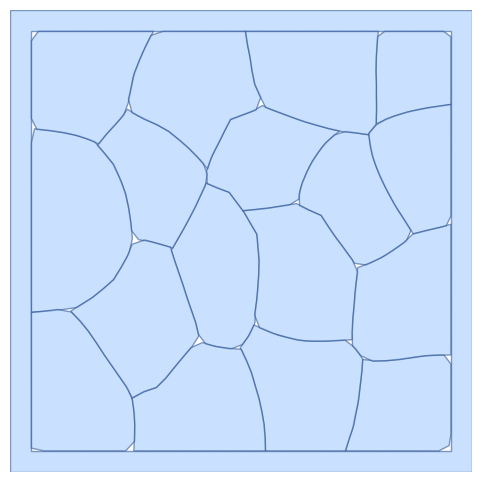

    round  6  worstFlat 0.920747  kappa 4.00000  sizeCV 0.1800  phi 0.99901  side 4.1252  excess 4.83e-05  cond 1.0e+00  [relax 176.3s  hold   3.2s  total   1076s]


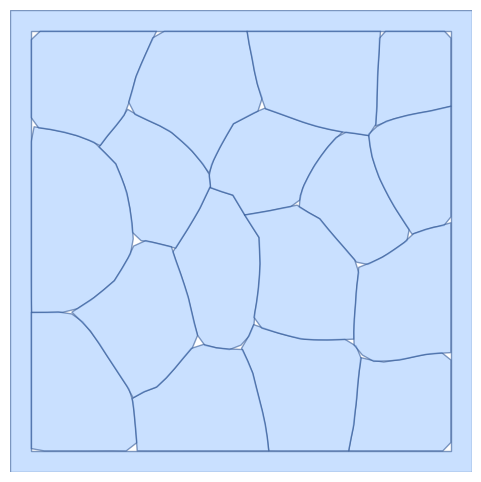

    round  7  worstFlat 0.960373  kappa 4.00000  sizeCV 0.1800  phi 0.99911  side 4.1250  excess 5.05e-05  cond 1.0e+00  [relax 182.8s  hold  22.3s  total   1282s]


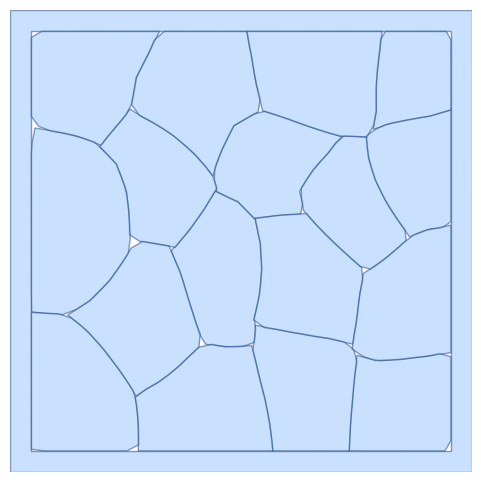

In [ ]:
import time

history = []
_t0 = time.time()
for stage in range(stages):
    print(f"\n=== stage {stage + 1}: n {count()} -> {count() // 2}", flush = True)
    packing.selectFlattening(stride = 2)

    # PER VERTEX, not collective, and this is the correction that made the ramp work. A single row
    # holding the SUM of d/(a+b) is either degenerate or ineffective and cannot be both:
    #   aimed at exactly `count` it does force every term to 1 (each is at most 1, so the sum reaches
    #     count only if all do) -- but that is a MAXIMUM of the quantity, so the row's gradient
    #     vanishes there. Measured: conditioning 5.97e-01 -> 2.02e-10, then LAPACK failed outright.
    #   backed off to 0.99 count it is well conditioned but holds only the MEAN. Measured in free
    #     space it hit 0.99000 exactly with the worst vertex at 0.83; in a packing it moved the worst
    #     from 0.71 to 0.80 over eight rounds and was going nowhere.
    # One row per selected vertex has neither problem: each is pulled toward its own target, and the
    # target is walked from where that vertex started to just short of flat. Measured: 0.999999 on
    # every vertex with conditioning 1.0.
    packing.setConstraints(equilateral = kappa, edge = False, area = [1], flatten = True)
    start = packing.getFlatness().copy()
    print(f"  {start.size} vertices selected   worstFlat {start.min():.5f}   "
          f"conditioning {packing.constraintConditioning():.2e}   goal {flatGoal}", flush = True)

    for step in range(flattenRounds):
        blend = (step + 1) / flattenRounds
        packing.setFlatTargets((1.0 - blend) * start + blend * flatGoal)
        packing.constraints.projectPositions(packing.packing)
        # CHEAP inside the ramp. holdExcessEnergy defaults to maxRounds = 80 at maxSteps = 20000 PER
        # ROUND, each a full minimizer -- up to 1.6M steps for one call, and this loop runs it 24 times
        # over the cascade. Between consecutive ramp steps the geometry barely moves, so the density
        # needs a correction, not a search. The full budget is spent once per stage, after the removal.
        _t = time.time()
        packing.minimizeFireLBFGS(maxUnbalancedForce = 1e-9, maxSteps = 1500,
                                  coarseness = coarseness, patience = patience)
        _tRelax = time.time() - _t
        _t = time.time()
        got, phi = packing.holdExcessEnergy(excess, minimizer = "fireLbfgs",
                                            maxRounds = 6, maxSteps = 3000)
        _tHold = time.time() - _t
        worst = float(packing.getFlatness().min())
        history.append(dict(stage = stage, step = step, count = count(), worstFlat = worst,
                            kappa = float(np.nanmean(packing.getShapeIndices()[:N])),
                            sizeCV = packing.getSizePolydispersity(), side = side(),
                            phi = packing.getPackingFraction(), excess = got,
                            overlap = packing.getPairOverlapArea(), corners = corners()))
        print(f"    round {step + 1:2d}  worstFlat {worst:.6f}  kappa {history[-1]['kappa']:.5f}  "
              f"sizeCV {history[-1]['sizeCV']:.4f}  phi {history[-1]['phi']:.5f}  "
              f"side {history[-1]['side']:.4f}  excess {got:.2e}  "
              f"cond {packing.constraintConditioning():.1e}  "
              f"[relax {_tRelax:5.1f}s  hold {_tHold:5.1f}s  total {time.time() - _t0:6.0f}s]",
              flush = True)
        packing.draw()
        plt.show()

    print(f"  end of ramp: worstFlat {packing.getFlatness().min():.8f}", flush = True)

    # EXACT removal, or a refusal that says why. Drop the flatness rows first -- they describe vertices
    # that are about to stop existing.
    packing.setConstraints(equilateral = kappa, edge = False, area = [1])
    try:
        packing.halveNumEdges()
    except ValueError as error:
        print(f"  !! halveNumEdges REFUSED: {error}")
        print(f"     the selected vertices are not flat enough -- raise flattenRounds or flatGoal.")
        break

    # SIZE SQUEEZE, its own phase because the area family is now the only moment family live and can
    # carry two exponents again. One step of the walk to monodisperse per stage.
    packing.setConstraints(equilateral = kappa, edge = False, area = [1, 2])
    target = sizeSpread * (1.0 - (stage + 1) / stages)
    packing._distributionConstraints().setReference("area", areaMoments(target))
    packing.constraints.projectPositions(packing.packing)
    packing.minimizeFireLBFGS(maxUnbalancedForce = 1e-9, maxSteps = 4000, coarseness = coarseness,
                              patience = patience)
    got, phi = packing.holdExcessEnergy(excess, minimizer = "fireLbfgs", maxRounds = 20)
    report(f"after halving to n = {count()}")
    packing.draw(forces = packing.getForces())
    plt.show()

In [ ]:
packing.draw()

In [ ]:
figure, axes = plt.subplots(1, 4, figsize = (19, 4))
x = np.arange(len(history))
boundary = [i for i in range(1, len(history)) if history[i]["count"] != history[i-1]["count"]]
for ax in axes:
    for b in boundary:
        ax.axvline(b - 0.5, color = "0.7", linestyle = ":")   # where a halving happened
axes[0].plot(x, [h["worstFlat"] for h in history], marker = "o")
axes[0].axhline(1.0, linestyle = "--", label = "flat (removable)")
axes[0].set_ylabel("worst d/(a+b) over selected"); axes[0].legend()
axes[1].plot(x, [h["sizeCV"] for h in history], marker = "o")
axes[1].set_ylabel("size CV (areas)")
axes[2].plot(x, [h["phi"] for h in history], marker = "o")
if maxSquarePhi is not None:
    axes[2].axhline(maxSquarePhi, linestyle = "--", label = f"max possible for {N} squares")
    axes[2].legend()
axes[2].set_ylabel("phi")
axes[3].plot(x, [h["side"] for h in history], marker = "o")
if bestKnown is not None:
    # The record applies to SQUARES, so it bounds the END of the run only; a compliant 32-gon is a
    # different object and legitimately packs denser.
    axes[3].plot([len(history) - 1], [bestKnown], marker = "*", markersize = 14,
                 label = f"record for {N} SQUARES")
    axes[3].legend()
axes[3].set_ylabel("side"); axes[3].invert_yaxis()
for ax in axes:
    ax.set_xlabel("ramp step (dotted = a halving)")
plt.tight_layout(); plt.show()

## 4. Decompress -- once

Nothing is imposed here. At n = 4 the constraint set has zero shape freedom: equilateral edges plus a
shape index of 4 make an equilateral quadrilateral, which is a rhombus with `kappa = 4 / sqrt(sin
theta)`, so `theta = 90` degrees and it is a square. The only thing left is to take the overlap out.

The search is now rigid-body -- translations and rotations only -- which is exactly the problem a
direct rigid-square search solves. So whatever this beats that baseline by is attributable to the
ARRANGEMENT the cascade handed over, which is the claim being tested.

Two checks decide whether the answer means anything, and both come from published data rather than from
this code: the side against the PROVED optimum, and phi against the densest packing five unit squares
can have. A run that lands below either is broken, not brilliant.

In [ ]:
print(f"before decompression: n {count()}  corners {corners():.4f} deg  "
      f"kappa {np.nanmean(packing.getShapeIndices()[:N]):.6f}  "
      f"residual {packing.constraintResidual():.2e}  phi {packing.getPackingFraction():.5f}")

final = packing.energySweep(minimizer = "fireLbfgs", annealShape = False, finishRigid = False,
                            wallTolerance = 5e-3 * meanEdge, excessEnergy = excess,
                            progressBar = "text", drawEvery = 1)
print(final)
if rigidBaseline is not None:
    print(f"rigid squares direct: side {rigidBaseline:.4f}")
if final.packed:
    achieved = float(np.sqrt(N / final.phi))
    print(f"cascade -> squares  : side {achieved:.4f}")
    print(records.describe(N, achieved = achieved))
    if maxSquarePhi is not None and final.phi > maxSquarePhi * (1.0 + 1e-9):
        print(f"  !! phi {final.phi:.5f} exceeds the densest possible {maxSquarePhi:.5f} by "
              f"{final.phi / maxSquarePhi:.2f}x -- the polygons overlap or have left the box, so "
              f"nothing here is a packing result.")
print(f"final corners: worst |angle - 90| = {corners():.4f} deg")
packing.draw(forces = packing.getForces())
plt.show()

# How much slack is left? The sweep stops on the WALL criterion, so the density at which the squares
# actually touch each other is a separate -- and higher -- number.
base = packing.getPackingFraction()
print("\nremaining slack (pair overlap is the honest jamming test):")
for factor in (1.00, 1.01, 1.02, 1.03, 1.05):
    packing.setPackingFraction(base * factor)
    packing.minimizeFireLBFGS(maxUnbalancedForce = 1e-8, maxSteps = 4000, coarseness = coarseness,
                              patience = patience)
    print(f"  x{factor:.2f}  side {np.sqrt(N / packing.getPackingFraction()):.4f}  "
          f"pairOverlap {packing.getPairOverlapArea():.3e}  "
          f"wallPenetration {packing.getWallPenetration():.3e}")
packing.setPackingFraction(base)
packing.minimizeFireLBFGS(maxUnbalancedForce = 1e-8, maxSteps = 4000, coarseness = coarseness,
                          patience = patience)